# 04 — Tabular feature EDA

**Child Mind Institute — Problematic Internet Use**

Этот ноутбук объединяет две задачи:

1. **Feature distributions** — какие допустимые tabular features доступны, как они распределены, насколько они skewed, где есть подозрительные значения и как соотносятся train/test.
2. **Feature–target relationships** — как эти признаки связаны с `sii`, если исключить `PCIAT-*`, `id` и сам target.

Таким образом, ноутбук заменяет два отдельных файла:

- `04_feature_distributions.ipynb`
- `05_feature_target_relationships.ipynb`

> Actigraphy/parquet данные здесь не используются.


## 1. Imports and data loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, pearsonr, rankdata, spearmanr
from sklearn.feature_selection import mutual_info_classif

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

TARGET = "sii"
ID_COL = "id"
AGE_COL = "Basic_Demos-Age"
RANDOM_STATE = 42


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
DATA_DICT_PATH = DATA_DIR / "data_dictionary.csv"

for path in [TRAIN_PATH, TEST_PATH, DATA_DICT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
data_dict = pd.read_csv(DATA_DICT_PATH)

labeled = train.loc[train[TARGET].notna()].copy()
MODEL_FEATURES = [c for c in test.columns if c != ID_COL]

feature_meta = (
    data_dict.loc[data_dict["Field"].isin(MODEL_FEATURES)]
    .set_index("Field")
    .reindex(MODEL_FEATURES)
)

NUMERIC_MEASURE_COLS = [
    c for c in MODEL_FEATURES
    if feature_meta.loc[c, "Type"] in {"float", "int"}
]

CATEGORICAL_INT_COLS = [
    c for c in MODEL_FEATURES
    if feature_meta.loc[c, "Type"] == "categorical int"
]

STRING_COLS = [
    c for c in MODEL_FEATURES
    if feature_meta.loc[c, "Type"] == "str"
]

CATEGORICAL_COLS = CATEGORICAL_INT_COLS + STRING_COLS

print("Train:", train.shape)
print("Test:", test.shape)
print("Labeled rows:", labeled.shape)
print("Model features:", len(MODEL_FEATURES))
print("Numeric measurements:", len(NUMERIC_MEASURE_COLS))
print("Categorical int:", len(CATEGORICAL_INT_COLS))
print("String categories:", len(STRING_COLS))


Train: (3960, 82)
Test: (20, 59)
Labeled rows: (2736, 82)
Model features: 58
Numeric measurements: 37
Categorical int: 11
String categories: 10


## 2. Feature taxonomy

Не разделяем признаки только по pandas `dtype`. Используем `data_dictionary.csv`, потому что часть колонок имеет тип `categorical int` и по смыслу должна анализироваться как категориальная.


In [3]:
type_counts = (
    feature_meta["Type"]
    .value_counts(dropna=False)
    .rename("n_features")
    .to_frame()
)

display(type_counts)


,n_features
Type,
float,24
int,13
categorical int,11
str,10


## 3. Numeric feature summary

In [4]:
numeric_rows = []

for col in NUMERIC_MEASURE_COLS:
    s = train[col]
    x = s.dropna()

    numeric_rows.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "description": feature_meta.loc[col, "Description"],
        "n_available": len(x),
        "missing_%": s.isna().mean() * 100,
        "n_unique": x.nunique(),
        "mean": x.mean(),
        "std": x.std(),
        "min": x.min(),
        "p01": x.quantile(0.01),
        "p25": x.quantile(0.25),
        "median": x.median(),
        "p75": x.quantile(0.75),
        "p99": x.quantile(0.99),
        "max": x.max(),
        "skew": x.skew(),
    })

numeric_summary = (
    pd.DataFrame(numeric_rows)
    .sort_values(["instrument", "feature"])
    .reset_index(drop=True)
)

display(numeric_summary.round(3))


,feature,instrument,description,n_available,missing_%,n_unique,mean,std,min,p01,p25,median,p75,p99,max,skew
0,BIA-BIA_BMC,Bio-electric Impedance Analysis,Bone Mineral Content,1991,49.722,1986,6.720,92.586,-7.790,-0.638,2.967,3.923,5.461,12.071,4115.360,43.997
1,BIA-BIA_BMI,Bio-electric Impedance Analysis,Body Mass Index,1991,49.722,1803,19.367,5.048,0.048,13.067,15.914,17.966,21.461,37.259,53.924,1.770
2,BIA-BIA_BMR,Bio-electric Impedance Analysis,Basal Metabolic Rate,1991,49.722,1965,1237.018,1872.383,813.397,871.637,1004.710,1115.380,1310.360,2127.472,83152.200,42.212
3,BIA-BIA_DEE,Bio-electric Impedance Analysis,Daily Energy Expenditure,1991,49.722,1980,2064.694,2836.246,1073.450,1177.134,1605.785,1863.980,2218.145,3898.181,124728.000,40.788
4,BIA-BIA_ECW,Bio-electric Impedance Analysis,Extracellular Water,1991,49.722,1986,20.825,73.266,1.789,4.516,11.110,15.928,25.162,54.200,3233.000,42.442
5,BIA-BIA_FFM,Bio-electric Impedance Analysis,Fat Free Mass,1991,49.722,1985,74.022,199.434,28.900,35.104,49.278,61.066,81.834,168.867,8799.080,42.212
6,BIA-BIA_FFMI,Bio-electric Impedance Analysis,Fat Free Mass Index,1991,49.722,1945,15.031,5.793,7.865,12.459,13.408,14.092,15.431,24.491,217.771,23.801
7,BIA-BIA_FMI,Bio-electric Impedance Analysis,Fat Mass Index,1991,49.722,1985,4.336,6.356,-194.163,-0.730,2.307,3.699,5.988,17.199,28.252,-16.692
8,BIA-BIA_Fat,Bio-electric Impedance Analysis,Body Fat Percentage,1991,49.722,1988,16.855,199.372,-8745.080,-3.663,8.602,16.175,30.273,101.372,153.820,-42.773
9,BIA-BIA_ICW,Bio-electric Impedance Analysis,Intracellular Water,1991,49.722,1980,33.173,56.272,14.489,18.994,24.464,28.856,35.476,71.471,2457.910,40.440


### Most skewed numeric features

In [5]:
skew_summary = (
    numeric_summary[
        ["feature", "instrument", "n_available", "missing_%", "skew"]
    ]
    .assign(abs_skew=lambda x: x["skew"].abs())
    .sort_values("abs_skew", ascending=False)
)

display(skew_summary.head(20).round(3))


,feature,instrument,n_available,missing_%,skew,abs_skew
0,BIA-BIA_BMC,Bio-electric Impedance Analysis,1991,49.722,43.997,43.997
10,BIA-BIA_LDM,Bio-electric Impedance Analysis,1991,49.722,42.871,42.871
8,BIA-BIA_Fat,Bio-electric Impedance Analysis,1991,49.722,-42.773,42.773
4,BIA-BIA_ECW,Bio-electric Impedance Analysis,1991,49.722,42.442,42.442
5,BIA-BIA_FFM,Bio-electric Impedance Analysis,1991,49.722,42.212,42.212
2,BIA-BIA_BMR,Bio-electric Impedance Analysis,1991,49.722,42.212,42.212
13,BIA-BIA_TBW,Bio-electric Impedance Analysis,1991,49.722,41.718,41.718
3,BIA-BIA_DEE,Bio-electric Impedance Analysis,1991,49.722,40.788,40.788
9,BIA-BIA_ICW,Bio-electric Impedance Analysis,1991,49.722,40.440,40.440
12,BIA-BIA_SMM,Bio-electric Impedance Analysis,1991,49.722,39.107,39.107


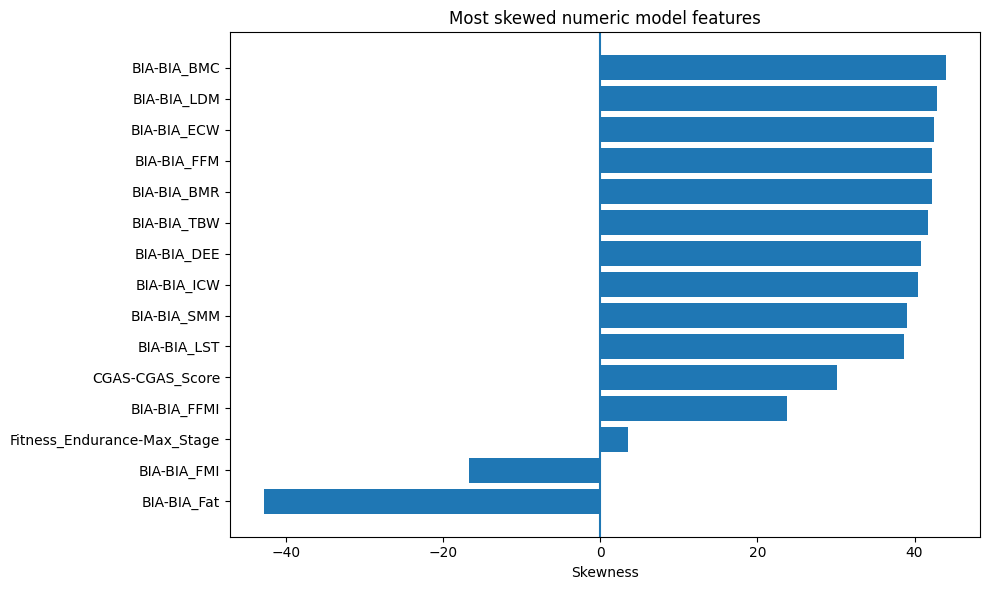

In [6]:
top_skew = skew_summary.dropna(subset=["skew"]).head(15).sort_values("skew")

plt.figure(figsize=(10, 6))
plt.barh(top_skew["feature"], top_skew["skew"])
plt.axvline(0)
plt.xlabel("Skewness")
plt.ylabel("")
plt.title("Most skewed numeric model features")
plt.tight_layout()
plt.show()


### Representative numeric distributions

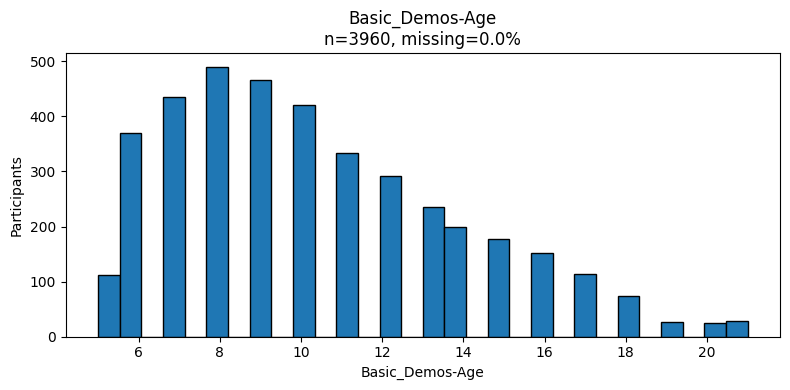

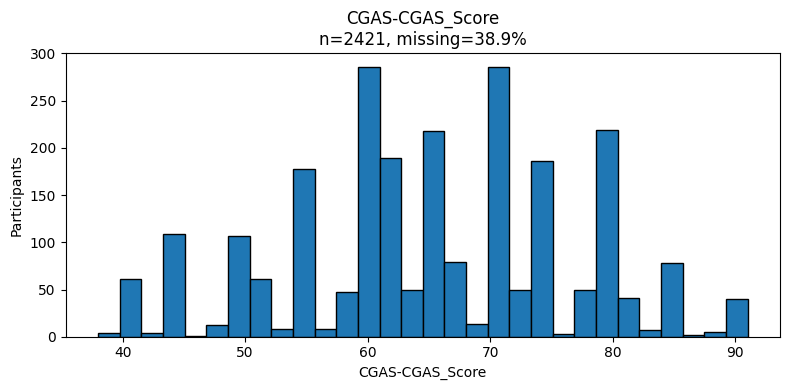

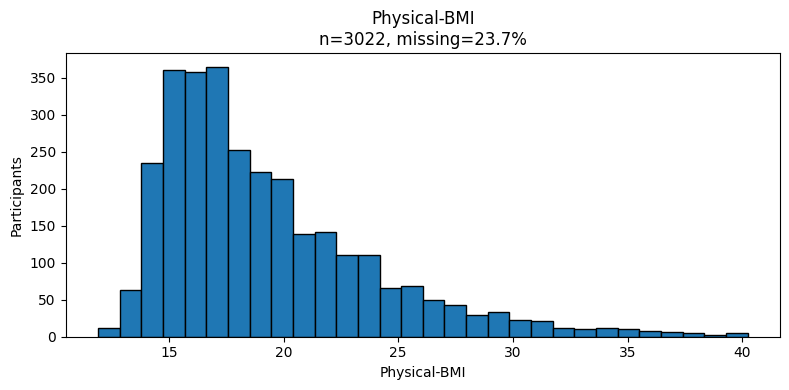

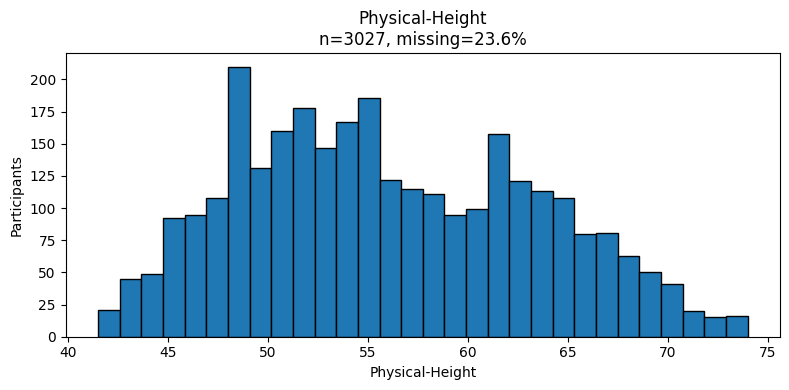

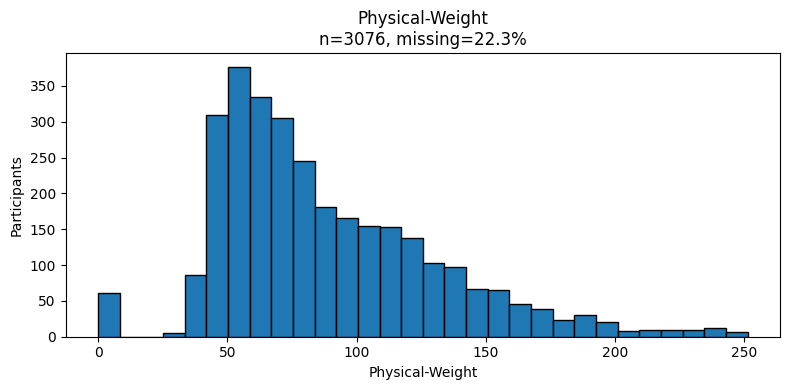

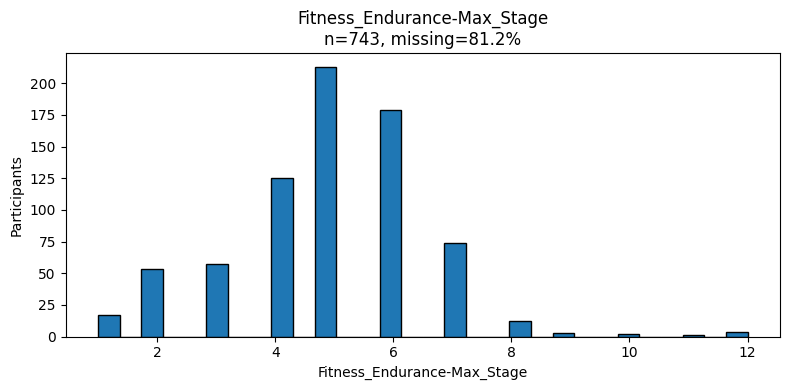

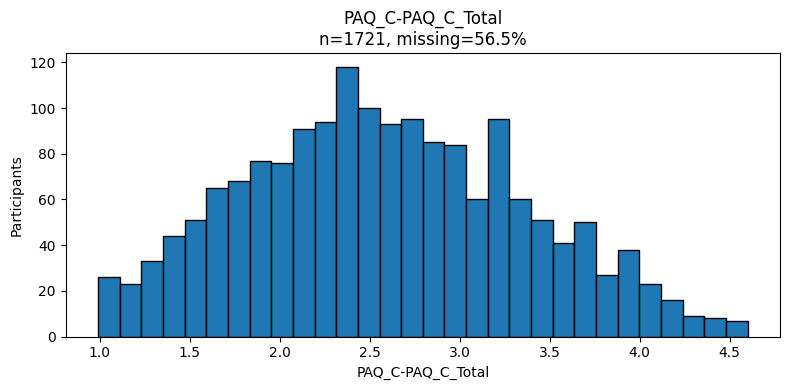

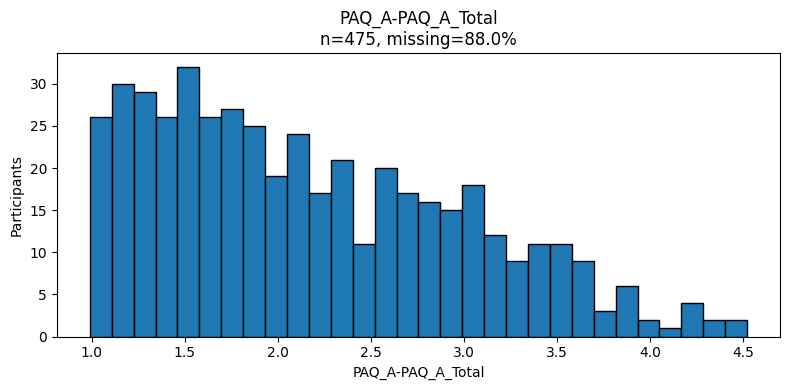

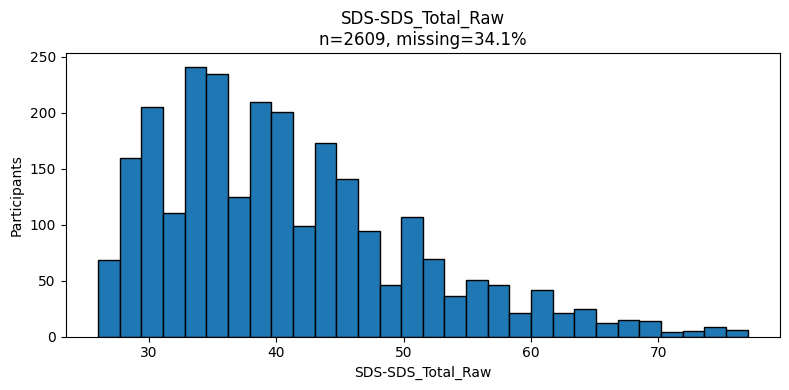

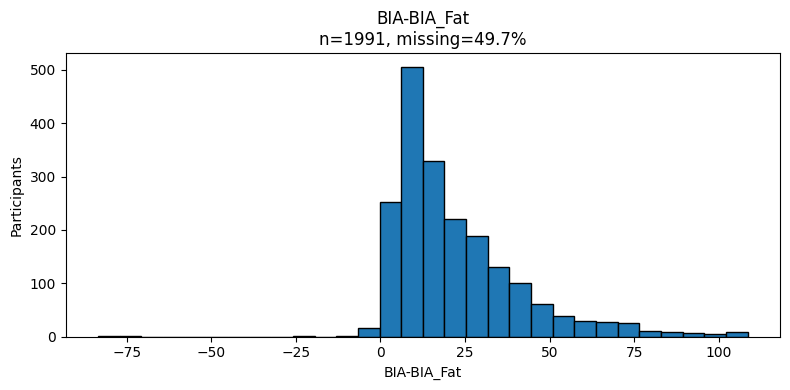

In [7]:
PLOT_FEATURES = [
    "Basic_Demos-Age",
    "CGAS-CGAS_Score",
    "Physical-BMI",
    "Physical-Height",
    "Physical-Weight",
    "Fitness_Endurance-Max_Stage",
    "PAQ_C-PAQ_C_Total",
    "PAQ_A-PAQ_A_Total",
    "SDS-SDS_Total_Raw",
    "BIA-BIA_Fat",
]

PLOT_FEATURES = [
    c for c in PLOT_FEATURES
    if c in NUMERIC_MEASURE_COLS
]

def plot_numeric_distribution(df, feature, clip=(0.005, 0.995), bins=30):
    s = df[feature].dropna()

    if len(s) == 0:
        return

    plot_s = s

    if clip is not None and s.nunique() > 2:
        low, high = s.quantile(list(clip))
        plot_s = s[s.between(low, high)]

    plt.figure(figsize=(8, 4))
    plt.hist(plot_s, bins=bins, edgecolor="black")
    plt.xlabel(feature)
    plt.ylabel("Participants")
    plt.title(
        f"{feature}\n"
        f"n={len(s)}, missing={df[feature].isna().mean():.1%}"
    )
    plt.tight_layout()
    plt.show()

for feature in PLOT_FEATURES:
    plot_numeric_distribution(train, feature)


## 4. Categorical feature distributions

In [8]:
categorical_int_summary = []

for col in CATEGORICAL_INT_COLS:
    values = sorted(train[col].dropna().unique().tolist())

    categorical_int_summary.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "description": feature_meta.loc[col, "Description"],
        "dictionary_values": feature_meta.loc[col, "Values"],
        "value_labels": feature_meta.loc[col, "Value Labels"],
        "observed_values": values,
        "n_unique": len(values),
        "missing_%": train[col].isna().mean() * 100,
    })

categorical_int_summary = pd.DataFrame(categorical_int_summary)

display(categorical_int_summary)


,feature,instrument,description,dictionary_values,value_labels,observed_values,n_unique,missing_%
0,Basic_Demos-Sex,Demographics,Sex of participant,"0,1","0=Male, 1=Female","[0, 1]",2,0.000000
1,FGC-FGC_CU_Zone,FitnessGram Child,Curl up fitness zone,"0,1","0=Needs Improvement, 1=Healthy Fitness Zone","[0.0, 1.0]",2,42.373737
2,FGC-FGC_GSND_Zone,FitnessGram Child,Grip Strength fitness zone (non-dominant),"1,2,3","1=Weak, 2=Normal, 3=Strong","[1.0, 2.0, 3.0]",3,73.181818
3,FGC-FGC_GSD_Zone,FitnessGram Child,Grip Strength fitness zone (dominant),"1,2,3","1=Weak, 2=Normal, 3=Strong","[1.0, 2.0, 3.0]",3,73.156566
4,FGC-FGC_PU_Zone,FitnessGram Child,Push-up fitness zone,"0,1","0=Needs Improvement, 1=Healthy Fitness Zone","[0.0, 1.0]",2,42.651515
5,FGC-FGC_SRL_Zone,FitnessGram Child,Sit & Reach fitness zone (left side),"0,1","0=Needs Improvement, 1=Healthy Fitness Zone","[0.0, 1.0]",2,42.752525
6,FGC-FGC_SRR_Zone,FitnessGram Child,Sit & Reach fitness zone (right side),"0,1","0=Needs Improvement, 1=Healthy Fitness Zone","[0.0, 1.0]",2,42.702020
7,FGC-FGC_TL_Zone,FitnessGram Child,Trunk lift fitness zone,"0,1","0=Needs Improvement, 1=Healthy Fitness Zone","[0.0, 1.0]",2,42.297980
8,BIA-BIA_Activity_Level_num,Bio-electric Impedance Analysis,Activity Level,"1,2,3,4,5","1=Very Light, 2=Light, 3=Moderate, 4=Heavy, 5=...","[1.0, 2.0, 3.0, 4.0, 5.0]",5,49.722222
9,BIA-BIA_Frame_num,Bio-electric Impedance Analysis,Body Frame,"1,2,3","1=Small, 2=Medium, 3=Large","[1.0, 2.0, 3.0]",3,49.722222


In [9]:
string_summary = []

for col in STRING_COLS:
    observed = sorted(train[col].dropna().astype(str).unique())

    string_summary.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "description": feature_meta.loc[col, "Description"],
        "dictionary_values": feature_meta.loc[col, "Values"],
        "observed_values": observed,
        "n_unique": len(observed),
        "missing_%": train[col].isna().mean() * 100,
    })

string_summary = pd.DataFrame(string_summary)

display(string_summary)


,feature,instrument,description,dictionary_values,observed_values,n_unique,missing_%
0,Basic_Demos-Enroll_Season,Demographics,Season of enrollment,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,0.000000
1,CGAS-Season,Children's Global Assessment Scale,Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,35.479798
2,Physical-Season,Physical Measures,Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,16.414141
3,Fitness_Endurance-Season,FitnessGram Vitals and Treadmill,Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,66.969697
4,FGC-Season,FitnessGram Child,Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,15.505051
5,BIA-Season,Bio-electric Impedance Analysis,Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,45.833333
6,PAQ_A-Season,Physical Activity Questionnaire (Adolescents),Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,88.005051
7,PAQ_C-Season,Physical Activity Questionnaire (Children),Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,56.540404
8,SDS-Season,Sleep Disturbance Scale,Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,33.888889
9,PreInt_EduHx-Season,Internet Use,Season of participation,"Spring, Summer, Fall, Winter","[Fall, Spring, Summer, Winter]",4,10.606061


In [10]:
season_distribution = pd.DataFrame({
    col: (
        train[col]
        .value_counts(normalize=True)
        .mul(100)
    )
    for col in STRING_COLS
}).T

display(season_distribution.round(1))


,Fall,Spring,Summer,Winter
Basic_Demos-Enroll_Season,21.9,28.5,24.5,25.2
CGAS-Season,24.9,27.3,25.7,22.2
Physical-Season,23.7,28.1,23.9,24.3
Fitness_Endurance-Season,25.4,29.4,19.3,25.8
FGC-Season,22.8,29.7,25.2,22.3
BIA-Season,26.4,23.9,31.2,18.5
PAQ_A-Season,20.6,25.9,24.6,28.8
PAQ_C-Season,20.6,29.4,22.7,27.3
SDS-Season,23.6,27.2,24.3,24.9
PreInt_EduHx-Season,23.4,27.8,23.2,25.6


## 5. IQR-based outlier screening

In [11]:
outlier_rows = []

for col in NUMERIC_MEASURE_COLS:
    s = train[col].dropna()

    if len(s) < 4:
        continue

    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1

    if iqr == 0:
        low = q1
        high = q3
        n_out = 0
    else:
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = ((s < low) | (s > high)).sum()

    outlier_rows.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "n_available": len(s),
        "iqr_low": low,
        "iqr_high": high,
        "n_iqr_outliers": n_out,
        "outlier_%": 100 * n_out / len(s),
        "min": s.min(),
        "p01": s.quantile(0.01),
        "median": s.median(),
        "p99": s.quantile(0.99),
        "max": s.max(),
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values("outlier_%", ascending=False)
    .reset_index(drop=True)
)

display(outlier_summary.head(25).round(3))


,feature,instrument,n_available,iqr_low,iqr_high,n_iqr_outliers,outlier_%,min,p01,median,p99,max
0,Fitness_Endurance-Time_Mins,FitnessGram Vitals and Treadmill,740,1.500,13.500,56,7.568,0.000,0.000,7.000,15.000,20.000
1,BIA-BIA_FFMI,Bio-electric Impedance Analysis,1991,10.374,18.465,122,6.128,7.865,12.459,14.092,24.491,217.771
2,BIA-BIA_Fat,Bio-electric Impedance Analysis,1991,-23.904,62.779,118,5.927,-8745.080,-3.663,16.175,101.372,153.820
3,BIA-BIA_BMC,Bio-electric Impedance Analysis,1991,-0.774,9.202,111,5.575,-7.790,-0.638,3.923,12.071,4115.360
4,BIA-BIA_ICW,Bio-electric Impedance Analysis,1991,7.945,51.994,108,5.424,14.489,18.994,28.856,71.471,2457.910
5,FGC-FGC_SRL,FitnessGram Child,2305,1.000,17.000,123,5.336,0.000,0.000,9.000,17.000,21.700
6,BIA-BIA_FMI,Bio-electric Impedance Analysis,1991,-3.214,11.509,104,5.224,-194.163,-0.730,3.699,17.199,28.252
7,FGC-FGC_CU,FitnessGram Child,2322,-16.125,34.875,116,4.996,0.000,0.000,9.000,50.000,115.000
8,FGC-FGC_SRR,FitnessGram Child,2307,1.000,17.000,114,4.941,0.000,0.000,9.000,17.000,21.000
9,BIA-BIA_DEE,Bio-electric Impedance Analysis,1991,687.245,3136.685,94,4.721,1073.450,1177.134,1863.980,3898.181,124728.000


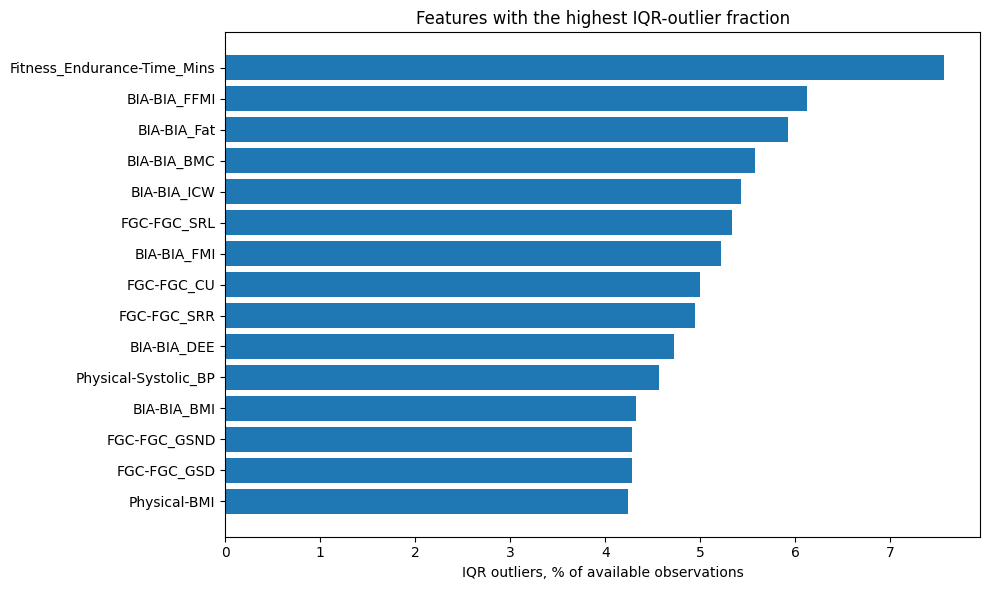

In [12]:
top_outliers = outlier_summary.head(15).sort_values("outlier_%")

plt.figure(figsize=(10, 6))
plt.barh(top_outliers["feature"], top_outliers["outlier_%"])
plt.xlabel("IQR outliers, % of available observations")
plt.ylabel("")
plt.title("Features with the highest IQR-outlier fraction")
plt.tight_layout()
plt.show()


### Extreme-value screening

In [13]:
extreme_summary = numeric_summary[
    [
        "feature",
        "instrument",
        "min",
        "p01",
        "median",
        "p99",
        "max",
    ]
].copy()

eps = 1e-12

extreme_summary["upper_gap_scaled"] = (
    (extreme_summary["max"] - extreme_summary["p99"]).abs()
    / ((extreme_summary["p99"] - extreme_summary["median"]).abs() + eps)
)

extreme_summary["lower_gap_scaled"] = (
    (extreme_summary["p01"] - extreme_summary["min"]).abs()
    / ((extreme_summary["median"] - extreme_summary["p01"]).abs() + eps)
)

extreme_summary["max_extreme_score"] = extreme_summary[
    ["upper_gap_scaled", "lower_gap_scaled"]
].max(axis=1)

extreme_summary = extreme_summary.sort_values(
    "max_extreme_score",
    ascending=False,
)

display(extreme_summary.head(20).round(3))


,feature,instrument,min,p01,median,p99,max,upper_gap_scaled,lower_gap_scaled,max_extreme_score
0,BIA-BIA_BMC,Bio-electric Impedance Analysis,-7.790,-0.638,3.923,12.071,4115.360,503.595,1.568,503.595
8,BIA-BIA_Fat,Bio-electric Impedance Analysis,-8745.080,-3.663,16.175,101.372,153.820,0.616,440.658,440.658
10,BIA-BIA_LDM,Bio-electric Impedance Analysis,4.636,7.558,16.439,44.426,3108.170,109.469,0.329,109.469
4,BIA-BIA_ECW,Bio-electric Impedance Analysis,1.789,4.516,15.928,54.200,3233.000,83.059,0.239,83.059
5,BIA-BIA_FFM,Bio-electric Impedance Analysis,28.900,35.104,61.066,168.867,8799.080,80.057,0.239,80.057
2,BIA-BIA_BMR,Bio-electric Impedance Analysis,813.397,871.637,1115.380,2127.472,83152.200,80.057,0.239,80.057
13,BIA-BIA_TBW,Bio-electric Impedance Analysis,20.589,24.542,44.987,124.043,5690.910,70.417,0.193,70.417
3,BIA-BIA_DEE,Bio-electric Impedance Analysis,1073.450,1177.134,1863.980,3898.181,124728.000,59.399,0.151,59.399
9,BIA-BIA_ICW,Bio-electric Impedance Analysis,14.489,18.994,28.856,71.471,2457.910,55.999,0.457,55.999
12,BIA-BIA_SMM,Bio-electric Impedance Analysis,4.656,13.871,27.415,94.939,3607.690,52.022,0.680,52.022


In [14]:
EXTREME_FEATURES_TO_INSPECT = (
    extreme_summary["feature"]
    .head(8)
    .tolist()
)

for col in EXTREME_FEATURES_TO_INSPECT:
    print(f"\n{col}")

    view = (
        train[[ID_COL, col]]
        .dropna()
        .sort_values(col)
    )

    display(
        pd.concat([view.head(3), view.tail(3)]).drop_duplicates()
    )



BIA-BIA_BMC


,id,BIA-BIA_BMC
238,0d74d0ed,-7.78961
3051,c41274a7,-6.40154
3451,dea0552b,-5.02683
1762,6f5a31ea,29.46300
3511,e252dcb6,401.00200
3205,cedf96c5,4115.36000



BIA-BIA_Fat


,id,BIA-BIA_Fat
3205,cedf96c5,-8745.080
3511,e252dcb6,-1044.510
3147,cadd4ae5,-217.522
2880,b9318815,126.010
3270,d3da09e8,129.226
921,374d3984,153.820



BIA-BIA_LDM


...

,id,BIA-BIA_BMR
2476,9d0670dd,813.397
2429,99f0cc53,825.733
3600,e8313da5,830.308
2490,9ddb06db,3987.680
3511,e252dcb6,11540.800
3205,cedf96c5,83152.200



BIA-BIA_TBW


,id,BIA-BIA_TBW
2476,9d0670dd,20.5892
2523,9fbfa81b,21.6173
3275,d42454d4,21.7241
2490,9ddb06db,268.0220
3511,e252dcb6,779.1140
3205,cedf96c5,5690.9100



BIA-BIA_DEE


,id,BIA-BIA_DEE
2429,99f0cc53,1073.45
3600,e8313da5,1079.40
219,0c4e2d68,1111.29
3774,f3020788,7994.08
3511,e252dcb6,17311.20
3205,cedf96c5,124728.00


## 6. Train/test compatibility

In [15]:
unseen_category_rows = []

for col in CATEGORICAL_COLS:
    train_values = set(train[col].dropna().astype(str))
    test_values = set(test[col].dropna().astype(str))

    unseen_category_rows.append({
        "feature": col,
        "train_categories": sorted(train_values),
        "test_categories": sorted(test_values),
        "unseen_in_train": sorted(test_values - train_values),
    })

unseen_categories = pd.DataFrame(unseen_category_rows)

display(unseen_categories)


,feature,train_categories,test_categories,unseen_in_train
0,Basic_Demos-Sex,"[0, 1]","[0, 1]",[]
1,FGC-FGC_CU_Zone,"[0.0, 1.0]","[0.0, 1.0]",[]
2,FGC-FGC_GSND_Zone,"[1.0, 2.0, 3.0]","[1.0, 2.0]",[]
3,FGC-FGC_GSD_Zone,"[1.0, 2.0, 3.0]","[1.0, 2.0]",[]
4,FGC-FGC_PU_Zone,"[0.0, 1.0]","[0.0, 1.0]",[]
5,FGC-FGC_SRL_Zone,"[0.0, 1.0]","[0.0, 1.0]",[]
6,FGC-FGC_SRR_Zone,"[0.0, 1.0]","[0.0, 1.0]",[]
7,FGC-FGC_TL_Zone,"[0.0, 1.0]","[0.0, 1.0]",[]
8,BIA-BIA_Activity_Level_num,"[1.0, 2.0, 3.0, 4.0, 5.0]","[2.0, 3.0, 5.0]",[]
9,BIA-BIA_Frame_num,"[1.0, 2.0, 3.0]","[1.0, 2.0]",[]


In [16]:
range_rows = []

for col in NUMERIC_MEASURE_COLS:
    train_s = train[col].dropna()
    test_s = test[col].dropna()

    if len(train_s) == 0 or len(test_s) == 0:
        continue

    outside = ((test_s < train_s.min()) | (test_s > train_s.max()))

    range_rows.append({
        "feature": col,
        "train_min": train_s.min(),
        "train_max": train_s.max(),
        "test_min": test_s.min(),
        "test_max": test_s.max(),
        "n_test_available": len(test_s),
        "n_test_outside_train_range": outside.sum(),
    })

range_check = pd.DataFrame(range_rows)

display(
    range_check.sort_values(
        "n_test_outside_train_range",
        ascending=False,
    ).round(3)
)


,feature,train_min,train_max,test_min,test_max,n_test_available,n_test_outside_train_range
0,Basic_Demos-Age,5.000,22.000,5.000,19.000,20,0
1,CGAS-CGAS_Score,25.000,999.000,50.000,80.000,8,0
2,Physical-BMI,0.000,59.132,14.036,30.095,13,0
3,Physical-Height,33.000,78.500,37.500,60.000,13,0
4,Physical-Weight,0.000,315.000,46.000,121.600,13,0
5,Physical-Waist_Circumference,18.000,50.000,22.000,30.000,5,0
6,Physical-Diastolic_BP,0.000,179.000,57.000,123.000,11,0
7,Physical-HeartRate,27.000,138.000,70.000,97.000,12,0
8,Physical-Systolic_BP,0.000,203.000,95.000,163.000,11,0
9,Fitness_Endurance-Max_Stage,0.000,28.000,4.000,6.000,3,0


In [17]:
median_compare = []

for col in NUMERIC_MEASURE_COLS:
    train_s = train[col].dropna()
    test_s = test[col].dropna()

    if len(train_s) == 0 or len(test_s) == 0:
        continue

    iqr = train_s.quantile(0.75) - train_s.quantile(0.25)

    median_compare.append({
        "feature": col,
        "train_median": train_s.median(),
        "test_median": test_s.median(),
        "train_iqr": iqr,
        "median_difference": test_s.median() - train_s.median(),
        "median_diff_in_train_iqr": (
            (test_s.median() - train_s.median()) / iqr
            if iqr != 0 else np.nan
        ),
        "n_test_available": len(test_s),
    })

median_compare = (
    pd.DataFrame(median_compare)
    .assign(abs_scaled_diff=lambda x: x["median_diff_in_train_iqr"].abs())
    .sort_values("abs_scaled_diff", ascending=False)
)

display(median_compare.head(20).round(3))


,feature,train_median,test_median,train_iqr,median_difference,median_diff_in_train_iqr,n_test_available,abs_scaled_diff
33,PAQ_A-PAQ_A_Total,2.010,1.040,1.290,-0.970,-0.752,1,0.752
18,FGC-FGC_TL,10.000,7.000,5.000,-3.000,-0.600,13,0.600
6,Physical-Diastolic_BP,68.000,63.000,15.000,-5.000,-0.333,11,0.333
13,FGC-FGC_GSND,20.050,16.500,11.500,-3.550,-0.309,5,0.309
5,Physical-Waist_Circumference,26.000,24.000,7.000,-2.000,-0.286,5,0.286
14,FGC-FGC_GSD,21.200,17.900,11.975,-3.300,-0.276,5,0.276
16,FGC-FGC_SRL,9.000,8.000,4.000,-1.000,-0.250,13,0.250
12,FGC-FGC_CU,9.000,6.000,12.750,-3.000,-0.235,13,0.235
34,PAQ_C-PAQ_C_Total,2.540,2.340,1.140,-0.200,-0.175,9,0.175
11,Fitness_Endurance-Time_Sec,28.000,33.000,30.250,5.000,0.165,3,0.165


## 7. Spearman correlation with SII

Так как `sii` — ordinal target, для первичного screening continuous features используем Spearman correlation.


In [18]:
spearman_rows = []

for col in NUMERIC_MEASURE_COLS:
    sub = labeled[[col, TARGET]].dropna()

    if len(sub) < 10 or sub[col].nunique() < 2:
        continue

    rho, p_value = spearmanr(sub[col], sub[TARGET])

    spearman_rows.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "n": len(sub),
        "rho": rho,
        "p_value": p_value,
        "abs_rho": abs(rho),
    })

spearman_summary = (
    pd.DataFrame(spearman_rows)
    .sort_values("abs_rho", ascending=False)
    .reset_index(drop=True)
)

display(spearman_summary.head(25).round(4))


,feature,instrument,n,rho,p_value,abs_rho
0,Basic_Demos-Age,Demographics,2736,0.3787,0.0,0.3787
1,Physical-Height,Physical Measures,2530,0.3775,0.0,0.3775
2,BIA-BIA_BMR,Bio-electric Impedance Analysis,1813,0.3673,0.0,0.3673
3,BIA-BIA_FFM,Bio-electric Impedance Analysis,1813,0.3673,0.0,0.3673
4,BIA-BIA_LDM,Bio-electric Impedance Analysis,1813,0.3667,0.0,0.3667
5,BIA-BIA_LST,Bio-electric Impedance Analysis,1813,0.3600,0.0,0.3600
6,BIA-BIA_ICW,Bio-electric Impedance Analysis,1813,0.3597,0.0,0.3597
7,BIA-BIA_SMM,Bio-electric Impedance Analysis,1813,0.3549,0.0,0.3549
8,Physical-Weight,Physical Measures,2572,0.3496,0.0,0.3496
9,BIA-BIA_TBW,Bio-electric Impedance Analysis,1813,0.3483,0.0,0.3483


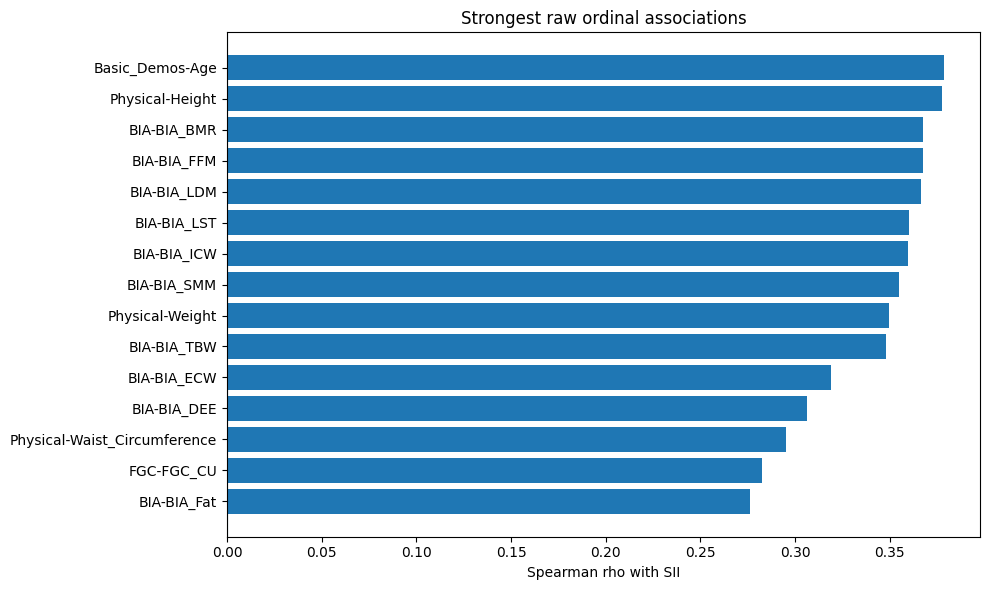

In [19]:
top_spearman = spearman_summary.head(15).sort_values("rho")

plt.figure(figsize=(10, 6))
plt.barh(top_spearman["feature"], top_spearman["rho"])
plt.axvline(0)
plt.xlabel("Spearman rho with SII")
plt.ylabel("")
plt.title("Strongest raw ordinal associations")
plt.tight_layout()
plt.show()


### Age confounding

Часть сильных raw correlations для physical/BIA features может быть объяснена тем, что и сами признаки, и `sii` связаны с возрастом. Поэтому next step — частичная корреляция с контролем `Basic_Demos-Age`.


## 8. Partial Spearman controlling for age

In [20]:
def partial_spearman_controlling_age(df, feature, target=TARGET, age=AGE_COL):
    sub = df[[feature, target, age]].dropna()

    if (
        len(sub) < 10
        or sub[feature].nunique() < 2
        or sub[age].nunique() < 2
    ):
        return np.nan, np.nan, len(sub)

    x_rank = rankdata(sub[feature].to_numpy())
    y_rank = rankdata(sub[target].to_numpy())
    age_rank = rankdata(sub[age].to_numpy())

    X = np.column_stack([np.ones(len(sub)), age_rank])

    beta_x = np.linalg.lstsq(X, x_rank, rcond=None)[0]
    beta_y = np.linalg.lstsq(X, y_rank, rcond=None)[0]

    residual_x = x_rank - X @ beta_x
    residual_y = y_rank - X @ beta_y

    r, p_value = pearsonr(residual_x, residual_y)

    return r, p_value, len(sub)


In [21]:
partial_rows = []

for col in NUMERIC_MEASURE_COLS:
    if col == AGE_COL:
        continue

    rho, p_value, n = partial_spearman_controlling_age(labeled, col)

    if np.isnan(rho):
        continue

    raw_match = spearman_summary.loc[
        spearman_summary["feature"].eq(col),
        "rho",
    ]

    raw_rho = raw_match.iloc[0] if len(raw_match) else np.nan

    partial_rows.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "n": n,
        "raw_rho": raw_rho,
        "partial_rho_age": rho,
        "p_value": p_value,
        "abs_partial_rho": abs(rho),
        "delta_abs_rho": abs(raw_rho) - abs(rho),
    })

partial_spearman = (
    pd.DataFrame(partial_rows)
    .sort_values("abs_partial_rho", ascending=False)
    .reset_index(drop=True)
)

display(partial_spearman.head(25).round(4))


,feature,instrument,n,raw_rho,partial_rho_age,p_value,abs_partial_rho,delta_abs_rho
0,SDS-SDS_Total_Raw,Sleep Disturbance Scale,2527,0.2307,0.2385,0.0000,0.2385,-0.0078
1,SDS-SDS_Total_T,Sleep Disturbance Scale,2525,0.2302,0.2383,0.0000,0.2383,-0.0081
2,Fitness_Endurance-Max_Stage,FitnessGram Vitals and Treadmill,731,-0.0785,-0.0948,0.0103,0.0948,-0.0163
3,Fitness_Endurance-Time_Mins,FitnessGram Vitals and Treadmill,728,-0.0750,-0.0891,0.0162,0.0891,-0.0141
4,BIA-BIA_ICW,Bio-electric Impedance Analysis,1813,0.3597,0.0890,0.0001,0.0890,0.2707
5,FGC-FGC_GSND,FitnessGram Child,872,0.1962,0.0880,0.0094,0.0880,0.1082
6,Physical-Height,Physical Measures,2530,0.3775,0.0842,0.0000,0.0842,0.2932
7,CGAS-CGAS_Score,Children's Global Assessment Scale,2342,-0.0730,-0.0762,0.0002,0.0762,-0.0032
8,Physical-Weight,Physical Measures,2572,0.3496,0.0752,0.0001,0.0752,0.2744
9,FGC-FGC_GSD,FitnessGram Child,871,0.1907,0.0748,0.0273,0.0748,0.1159


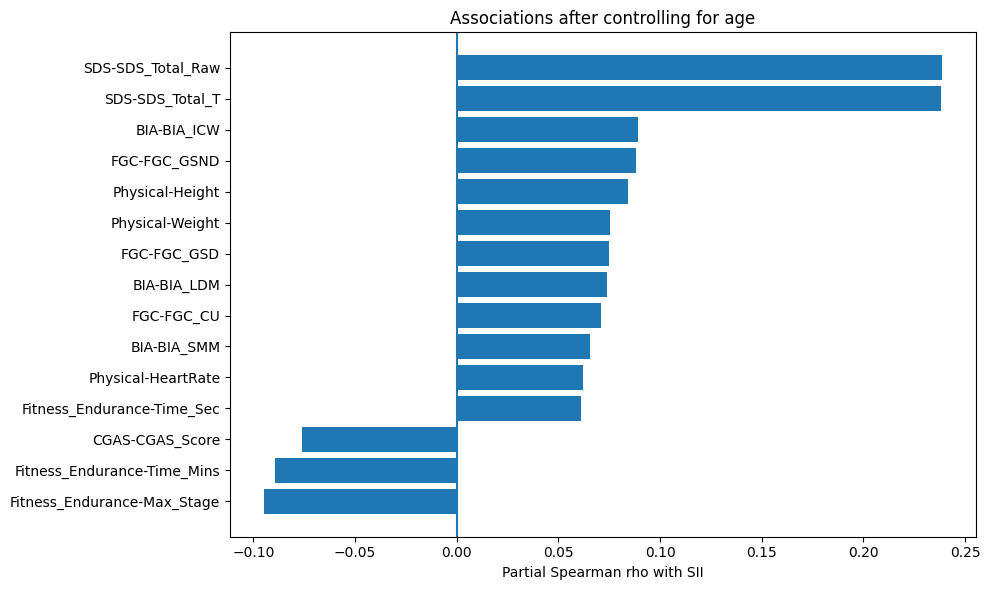

In [22]:
top_partial = partial_spearman.head(15).sort_values("partial_rho_age")

plt.figure(figsize=(10, 6))
plt.barh(top_partial["feature"], top_partial["partial_rho_age"])
plt.axvline(0)
plt.xlabel("Partial Spearman rho with SII")
plt.ylabel("")
plt.title("Associations after controlling for age")
plt.tight_layout()
plt.show()


In [23]:
comparison = (
    partial_spearman
    .sort_values("delta_abs_rho", ascending=False)
    .head(20)
)

display(
    comparison[
        ["feature", "raw_rho", "partial_rho_age", "delta_abs_rho", "n"]
    ].round(4)
)


,feature,raw_rho,partial_rho_age,delta_abs_rho,n
17,BIA-BIA_LST,0.3600,0.0508,0.3092,1813
32,BIA-BIA_ECW,0.3187,-0.0099,0.3088,1813
23,BIA-BIA_TBW,0.3483,0.0400,0.3083,1813
16,BIA-BIA_FFM,0.3673,0.0601,0.3072,1813
15,BIA-BIA_BMR,0.3673,0.0601,0.3072,1813
6,Physical-Height,0.3775,0.0842,0.2932,2530
10,BIA-BIA_LDM,0.3667,0.0741,0.2926,1813
12,BIA-BIA_SMM,0.3549,0.0656,0.2893,1813
8,Physical-Weight,0.3496,0.0752,0.2744,2572
4,BIA-BIA_ICW,0.3597,0.0890,0.2707,1813


## 9. Categorical features vs SII

In [24]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)

    if min(table.shape) < 2:
        return np.nan

    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = table.shape

    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)

    denom = min(k_corr - 1, r_corr - 1)

    if denom <= 0:
        return np.nan

    return np.sqrt(phi2_corr / denom)

categorical_rows = []

for col in CATEGORICAL_COLS:
    x = (
        labeled[col]
        .astype("object")
        .where(labeled[col].notna(), "__MISSING__")
        .astype(str)
    )

    v = cramers_v(x, labeled[TARGET].astype(int))

    categorical_rows.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "n_categories": x.nunique(),
        "missing_%": labeled[col].isna().mean() * 100,
        "cramers_v": v,
    })

categorical_association = (
    pd.DataFrame(categorical_rows)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

display(categorical_association.round(4))


,feature,instrument,n_categories,missing_%,cramers_v
0,PreInt_EduHx-computerinternet_hoursday,Internet Use,5,2.9971,0.2041
1,FGC-FGC_GSND_Zone,FitnessGram Child,4,68.4211,0.1445
2,FGC-FGC_GSD_Zone,FitnessGram Child,4,68.4211,0.1437
3,PAQ_A-Season,Physical Activity Questionnaire (Adolescents),5,86.7325,0.1284
4,Basic_Demos-Sex,Demographics,2,0.0000,0.0948
5,BIA-BIA_Frame_num,Bio-electric Impedance Analysis,4,33.7354,0.0812
6,Fitness_Endurance-Season,FitnessGram Vitals and Treadmill,5,53.9474,0.0803
7,PAQ_C-Season,Physical Activity Questionnaire (Children),5,47.3684,0.0711
8,FGC-FGC_SRL_Zone,FitnessGram Child,3,31.3962,0.0663
9,FGC-Season,FitnessGram Child,5,3.2529,0.0482


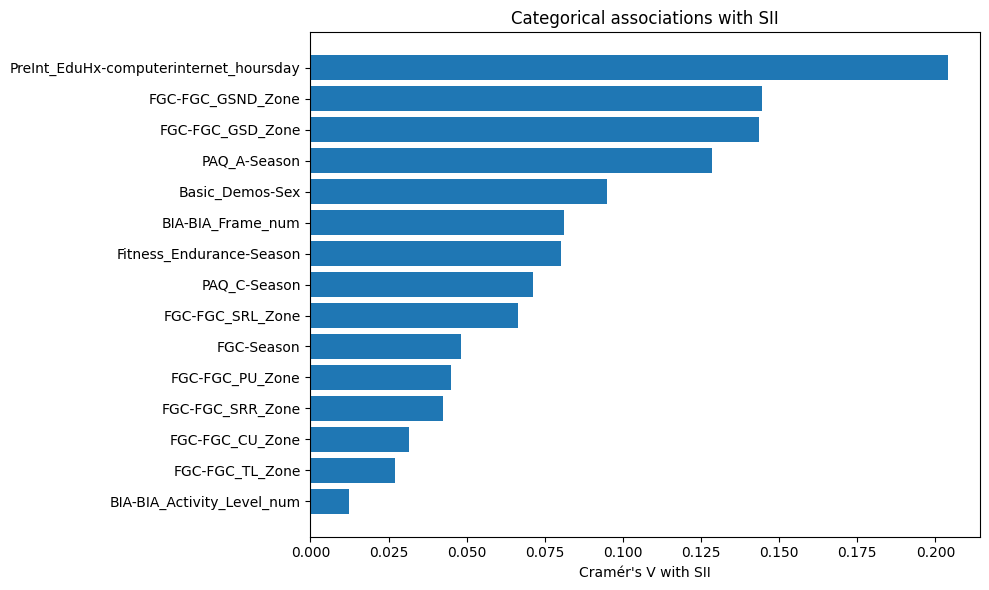

In [25]:
plot_cat = (
    categorical_association
    .dropna(subset=["cramers_v"])
    .head(15)
    .sort_values("cramers_v")
)

plt.figure(figsize=(10, 6))
plt.barh(plot_cat["feature"], plot_cat["cramers_v"])
plt.xlabel("Cramér's V with SII")
plt.ylabel("")
plt.title("Categorical associations with SII")
plt.tight_layout()
plt.show()


## 10. Univariate mutual information

In [26]:
mi_rows = []

y = labeled[TARGET].astype(int).to_numpy()

for col in MODEL_FEATURES:
    feature_type = feature_meta.loc[col, "Type"]

    if feature_type in {"float", "int"}:
        s = labeled[col].astype(float)

        if s.notna().sum() == 0:
            continue

        x = s.fillna(s.median()).to_numpy().reshape(-1, 1)
        discrete = False
    else:
        s = (
            labeled[col]
            .astype("object")
            .where(labeled[col].notna(), "__MISSING__")
            .astype(str)
        )

        codes, _ = pd.factorize(s)
        x = codes.reshape(-1, 1)
        discrete = True

    if np.unique(x).size < 2:
        continue

    mi = mutual_info_classif(
        x,
        y,
        discrete_features=discrete,
        random_state=RANDOM_STATE,
    )[0]

    mi_rows.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        "type": feature_type,
        "mutual_information": mi,
        "missing_%": labeled[col].isna().mean() * 100,
    })

mi_summary = (
    pd.DataFrame(mi_rows)
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

display(mi_summary.head(25).round(4))


,feature,instrument,type,mutual_information,missing_%
0,Basic_Demos-Age,Demographics,float,0.0886,0.0000
1,Physical-Weight,Physical Measures,float,0.0774,5.9942
2,Physical-Height,Physical Measures,float,0.0771,7.5292
3,BIA-BIA_LDM,Bio-electric Impedance Analysis,float,0.0704,33.7354
4,BIA-BIA_ICW,Bio-electric Impedance Analysis,float,0.0699,33.7354
5,PreInt_EduHx-computerinternet_hoursday,Internet Use,categorical int,0.0621,2.9971
6,BIA-BIA_DEE,Bio-electric Impedance Analysis,float,0.0525,33.7354
7,BIA-BIA_TBW,Bio-electric Impedance Analysis,float,0.0516,33.7354
8,BIA-BIA_BMR,Bio-electric Impedance Analysis,float,0.0506,33.7354
9,BIA-BIA_FFM,Bio-electric Impedance Analysis,float,0.0503,33.7354


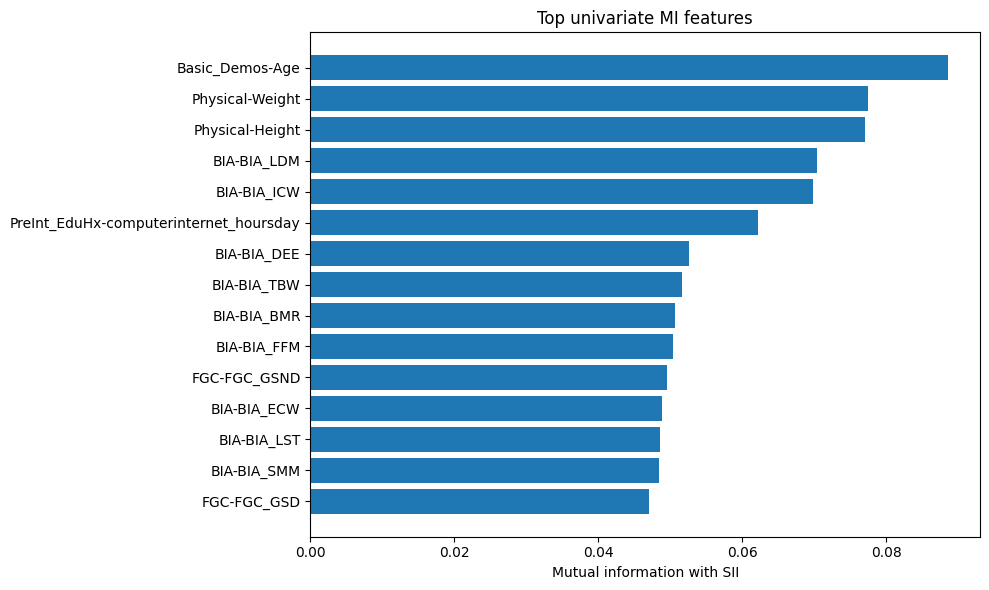

In [27]:
top_mi = mi_summary.head(15).sort_values("mutual_information")

plt.figure(figsize=(10, 6))
plt.barh(top_mi["feature"], top_mi["mutual_information"])
plt.xlabel("Mutual information with SII")
plt.ylabel("")
plt.title("Top univariate MI features")
plt.tight_layout()
plt.show()


## 11. Missingness itself vs SII

In [28]:
missing_by_class_rows = []
classes = sorted(labeled[TARGET].astype(int).unique())

for col in MODEL_FEATURES:
    rates = {}

    for cls in classes:
        cls_mask = labeled[TARGET].eq(cls)
        rates[cls] = labeled.loc[cls_mask, col].isna().mean() * 100

    values = list(rates.values())

    missing_by_class_rows.append({
        "feature": col,
        "instrument": feature_meta.loc[col, "Instrument"],
        **{f"missing_sii_{cls}_%": rates[cls] for cls in classes},
        "max_missing_gap_pp": max(values) - min(values),
    })

missingness_target = (
    pd.DataFrame(missing_by_class_rows)
    .sort_values("max_missing_gap_pp", ascending=False)
    .reset_index(drop=True)
)

display(missingness_target.head(25).round(2))


,feature,instrument,missing_sii_0_%,missing_sii_1_%,missing_sii_2_%,missing_sii_3_%,max_missing_gap_pp
0,FGC-FGC_GSND_Zone,FitnessGram Child,77.29,60.55,49.74,29.41,47.88
1,FGC-FGC_GSND,FitnessGram Child,77.04,60.27,49.21,29.41,47.63
2,FGC-FGC_GSD_Zone,FitnessGram Child,77.23,60.55,49.74,32.35,44.87
3,FGC-FGC_GSD,FitnessGram Child,77.04,60.27,49.21,32.35,44.69
4,Fitness_Endurance-Season,FitnessGram Vitals and Treadmill,49.12,56.71,65.87,88.24,39.11
5,PAQ_A-PAQ_A_Total,Physical Activity Questionnaire (Adolescents),91.78,83.70,73.54,61.76,30.02
6,PAQ_A-Season,Physical Activity Questionnaire (Adolescents),91.78,83.70,73.54,61.76,30.02
7,Fitness_Endurance-Max_Stage,FitnessGram Vitals and Treadmill,69.76,75.34,82.28,94.12,24.36
8,Fitness_Endurance-Time_Sec,FitnessGram Vitals and Treadmill,69.82,75.48,82.54,94.12,24.29
9,Fitness_Endurance-Time_Mins,FitnessGram Vitals and Treadmill,69.89,75.48,82.28,94.12,24.23


## 12. Class-wise distributions of selected features

C:\Users\HP\AppData\Local\Temp\ipykernel_7524\1856114135.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


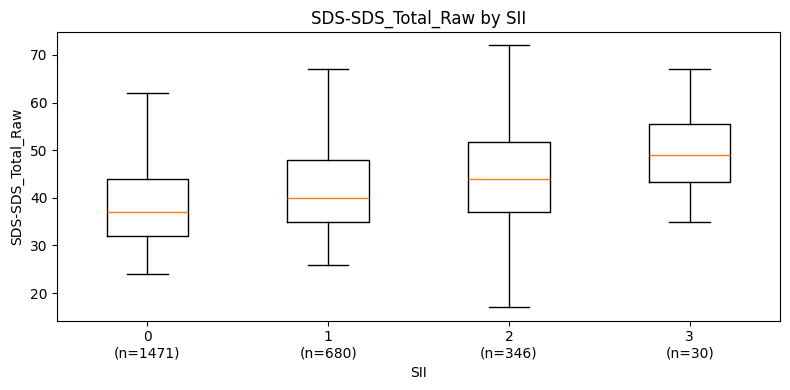

C:\Users\HP\AppData\Local\Temp\ipykernel_7524\1856114135.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


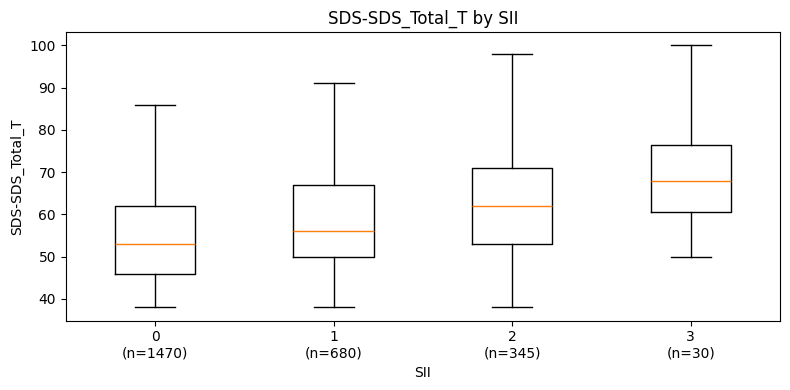

C:\Users\HP\AppData\Local\Temp\ipykernel_7524\1856114135.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


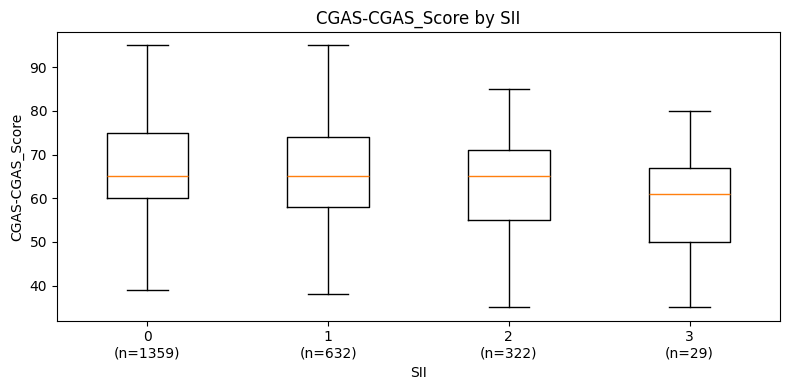

C:\Users\HP\AppData\Local\Temp\ipykernel_7524\1856114135.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


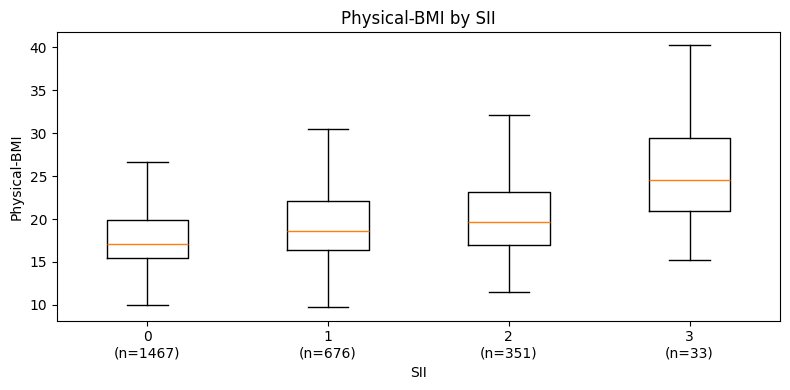

C:\Users\HP\AppData\Local\Temp\ipykernel_7524\1856114135.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


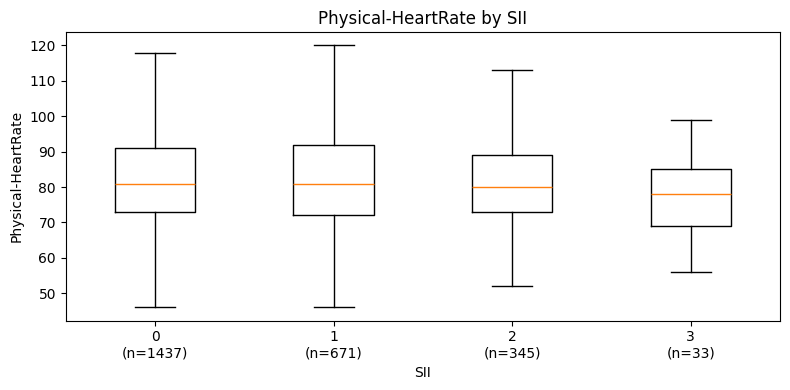

C:\Users\HP\AppData\Local\Temp\ipykernel_7524\1856114135.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


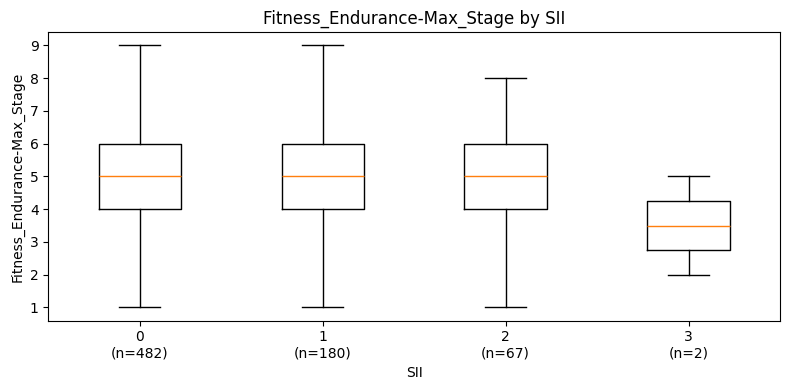

In [29]:
PLOT_FEATURES_TARGET = [
    "SDS-SDS_Total_Raw",
    "SDS-SDS_Total_T",
    "CGAS-CGAS_Score",
    "Physical-BMI",
    "Physical-HeartRate",
    "Fitness_Endurance-Max_Stage",
]

PLOT_FEATURES_TARGET = [
    col for col in PLOT_FEATURES_TARGET
    if col in labeled.columns
]

def plot_feature_by_sii(df, feature):
    groups = []
    labels = []

    for cls in sorted(df[TARGET].dropna().astype(int).unique()):
        values = df.loc[df[TARGET].eq(cls), feature].dropna()

        if len(values) == 0:
            continue

        groups.append(values)
        labels.append(f"{cls}\n(n={len(values)})")

    if not groups:
        return

    plt.figure(figsize=(8, 4))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.xlabel("SII")
    plt.ylabel(feature)
    plt.title(f"{feature} by SII")
    plt.tight_layout()
    plt.show()

for feature in PLOT_FEATURES_TARGET:
    plot_feature_by_sii(labeled, feature)


In [30]:
summary_features = list(dict.fromkeys(
    partial_spearman["feature"].head(10).tolist()
    + ["Basic_Demos-Age", "CGAS-CGAS_Score", "Physical-BMI"]
))

summary_features = [c for c in summary_features if c in labeled.columns]

class_summary_rows = []

for col in summary_features:
    for cls in sorted(labeled[TARGET].astype(int).unique()):
        s = labeled.loc[labeled[TARGET].eq(cls), col].dropna()

        if len(s) == 0:
            continue

        class_summary_rows.append({
            "feature": col,
            "sii": cls,
            "n": len(s),
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
        })

class_numeric_summary = pd.DataFrame(class_summary_rows)

display(class_numeric_summary.set_index(["feature", "sii"]).round(3))


n     mean   median     std
feature                     sii                                
SDS-SDS_Total_Raw           0    1471   39.247   37.000   9.585
                            1     680   42.175   40.000  10.109
                            2     346   45.173   44.000  11.139
                            3      30   50.300   49.000  10.363
SDS-SDS_Total_T             0    1470   55.406   53.000  12.204
                            1     680   59.219   56.000  12.911
                            2     345   63.046   62.000  14.144
                            3      30   69.767   68.000  13.201
Fitness_Endurance-Max_Stage 0     482    5.100    5.000   2.210
                            1     180    4.844    5.000   1.546
                            2      67    4.761    5.000   1.606
                            3       2    3.500    3.500   2.121
Fitness_Endurance-Time_Mins 0     480    7.515    8.000   3.268
                            1     179    7.240    7.000   2.961
                            2      67    7.030    7.000   3.055
                            3       2    4.500    4.500   4.950
BIA-BIA_ICW                 0    1064   31.475   26.706  75.191
                            1     480   33.243   31.024  10.146
                            2     245   38.672   34.138  28.524
                            3      24   47.998   48.872  10.682
FGC-FGC_GSND                0     366   20.605   17.800  10.900
                            1     290   22.189   19.650   9.145
                            2     192   24.093   22.350  11.309
                            3      24   27.083   25.650   8.355
Physical-Height             0    1470   53.683   52.500   6.853
                            1     676   57.986   57.775   7.074
                            2     351   60.266   60.500   6.592
                            3      33   65.259   65.000   4.211
CGAS-CGAS_Score             0    1359   65.868   65.000  11.916
                            1     632   64.684   65.000  11.766
                            2     322   63.696   65.000  11.160
                            3      29   58.586   61.000  11.416
Physical-Weight             0    1498   77.062   66.400  38.044
                            1     686   97.506   89.750  44.815
                            2     355  107.874  104.200  43.004
                            3      33  160.639  160.000  49.872
FGC-FGC_GSD                 0     366   21.548   19.200  10.106
                            1     290   23.079   21.150   9.271
                            2     192   25.245   23.150  12.409
                            3      23   29.539   27.000   9.501
Basic_Demos-Age             0    1594    9.255    9.000   3.126
                            1     730   11.118   11.000   3.304
                            2     378   12.291   12.000   3.280
                            3      34   14.676   14.000   2.383
Physical-BMI                0    1467   18.330   17.136   4.451
                            1     676   19.789   18.615   5.045
                            2     351   20.503   19.673   5.203
                            3      33   26.266   24.564   7.085

## 13. Consolidated screening table

In [31]:
ranking = (
    mi_summary[
        ["feature", "instrument", "type", "mutual_information", "missing_%"]
    ]
    .copy()
)

ranking = ranking.merge(
    spearman_summary[["feature", "rho", "abs_rho"]],
    on="feature",
    how="left",
)

ranking = ranking.merge(
    partial_spearman[
        ["feature", "partial_rho_age", "abs_partial_rho"]
    ],
    on="feature",
    how="left",
)

ranking = ranking.merge(
    categorical_association[["feature", "cramers_v"]],
    on="feature",
    how="left",
)

ranking = ranking.merge(
    missingness_target[["feature", "max_missing_gap_pp"]],
    on="feature",
    how="left",
)

display(
    ranking
    .sort_values("mutual_information", ascending=False)
    .head(30)
    .round(4)
)


,feature,instrument,type,mutual_information,missing_%,rho,abs_rho,partial_rho_age,abs_partial_rho,cramers_v,max_missing_gap_pp
0,Basic_Demos-Age,Demographics,float,0.0886,0.0000,0.3787,0.3787,NaN,NaN,NaN,0.0000
1,Physical-Weight,Physical Measures,float,0.0774,5.9942,0.3496,0.3496,0.0752,0.0752,NaN,3.1435
2,Physical-Height,Physical Measures,float,0.0771,7.5292,0.3775,0.3775,0.0842,0.0842,NaN,4.8380
3,BIA-BIA_LDM,Bio-electric Impedance Analysis,float,0.0704,33.7354,0.3667,0.3667,0.0741,0.0741,NaN,5.7734
4,BIA-BIA_ICW,Bio-electric Impedance Analysis,float,0.0699,33.7354,0.3597,0.3597,0.0890,0.0890,NaN,5.7734
5,PreInt_EduHx-computerinternet_hoursday,Internet Use,categorical int,0.0621,2.9971,NaN,NaN,NaN,NaN,0.2041,3.9683
6,BIA-BIA_DEE,Bio-electric Impedance Analysis,float,0.0525,33.7354,0.3061,0.3061,0.0506,0.0506,NaN,5.7734
7,BIA-BIA_TBW,Bio-electric Impedance Analysis,float,0.0516,33.7354,0.3483,0.3483,0.0400,0.0400,NaN,5.7734
8,BIA-BIA_BMR,Bio-electric Impedance Analysis,float,0.0506,33.7354,0.3673,0.3673,0.0601,0.0601,NaN,5.7734
9,BIA-BIA_FFM,Bio-electric Impedance Analysis,float,0.0503,33.7354,0.3673,0.3673,0.0601,0.0601,NaN,5.7734


## 14. Main findings to carry forward

1. Среди 58 допустимых model features доступны как continuous measurements, так и categorical variables; `categorical int` не должны обрабатываться как обычные continuous numbers.
2. Numeric features сильно различаются по масштабу, missingness и skewness; особенно выделяются признаки из блоков `BIA`, `Physical` и `Fitness`.
3. IQR-screening и extreme-value screening показывают наличие явно подозрительных значений, особенно в ряде `BIA`-признаков и в `CGAS-CGAS_Score`; их стоит проверить отдельно до обучения моделей.
4. В supplied `test.csv` не обнаружено unseen categories и значений, выходящих за полный observed train range, но из-за очень малого размера test эти проверки носят только sanity-check характер.
5. Raw Spearman ranking поднимает возраст, size-related physical measures и ряд BIA features, однако значительная часть этих связей ослабевает после контроля возраста.
6. Возраст является сильным confounder для интерпретации feature–target relationships в этом dataset.
7. После age adjustment среди числовых признаков особенно устойчиво выглядят `SDS-SDS_Total_Raw` и `SDS-SDS_Total_T`, что делает блок Sleep Disturbance Scale одним из наиболее интересных для дальнейшего анализа.
8. Mutual information полезен как дополнительный univariate ranking heuristic, но не заменяет полноценную validation-based feature importance.
9. Missingness сам по себе различается между классами `sii` и потенциально может нести predictive information, однако часть этого эффекта структурно связана с возрастом и полнотой обследования.

